In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn import svm
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm

In [2]:
import openml

# Abalone https://www.openml.org/search?type=data&status=active&id=44956
# Pobranie zbioru danych po ID
dataset = openml.datasets.get_dataset(44956)

# Zamiana na pandas DataFrame
X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

# Połączenie cech i etykiety w jeden DataFrame (opcjonalnie)
d = pd.concat([X, y], axis=1)

# Podgląd pierwszych wierszy
print(d.head())

print(len(d))

  sex  length  diameter  height  whole_weight  shucked_weight  cisvera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   shell_weight  rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  
4177


In [41]:
data = pd.DataFrame(d)
data

,sex,length,diameter,height,whole_weight,shucked_weight,cisvera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


<Axes: >

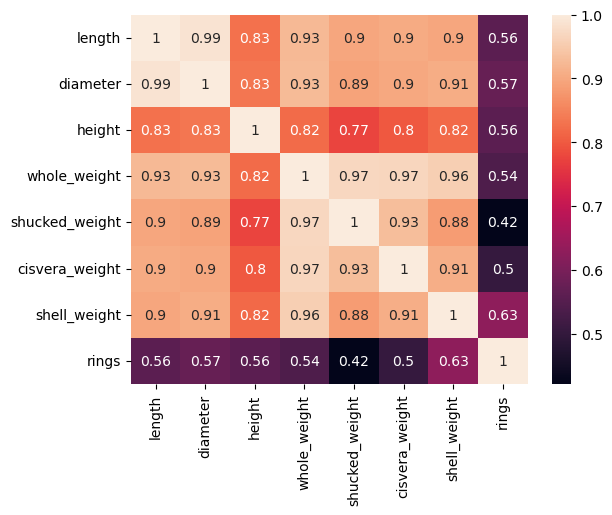

In [4]:
sns.heatmap(data.iloc[:, 1:].corr(), annot=True)

In [5]:
data.dtypes

sex               category
length             float64
diameter           float64
height             float64
whole_weight       float64
shucked_weight     float64
cisvera_weight     float64
shell_weight       float64
rings                uint8
dtype: object

In [6]:
data.head()

,sex,length,diameter,height,whole_weight,shucked_weight,cisvera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [7]:
cols = {"F":"Female", "M":"Male", "I":"Idk"}
coded_col = pd.get_dummies(data["sex"], columns=cols)
coded_col = coded_col.astype(int)
coded_col.rename(columns=cols, inplace=True)

data.drop(columns="sex", inplace=True)
data = pd.concat([data, coded_col], axis=1)

data

,length,diameter,height,whole_weight,shucked_weight,cisvera_weight,shell_weight,rings,Female,Idk,Male
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,0,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,0,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,1,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,0,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,1,0,0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,0,0,1
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,0,0,1
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,1,0,0


In [8]:
Y = data["rings"]
X = data.drop(columns="rings")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)
cv = KFold(n_splits = 10, shuffle=True, random_state=42)

n_feat_total = X_train.shape[1]

X_test

,length,diameter,height,whole_weight,shucked_weight,cisvera_weight,shell_weight,Female,Idk,Male
866,0.605,0.455,0.160,1.1035,0.4210,0.3015,0.325,0,0,1
1483,0.590,0.440,0.150,0.8725,0.3870,0.2150,0.245,0,0,1
599,0.560,0.445,0.195,0.9810,0.3050,0.2245,0.335,1,0,0
1702,0.635,0.490,0.170,1.2615,0.5385,0.2665,0.380,1,0,0
670,0.475,0.385,0.145,0.6175,0.2350,0.1080,0.215,0,0,1
...,...,...,...,...,...,...,...,...,...,...
3093,0.520,0.430,0.150,0.7280,0.3020,0.1575,0.235,1,0,0
1651,0.595,0.435,0.150,0.9000,0.4175,0.1700,0.265,1,0,0
2897,0.545,0.430,0.150,0.7420,0.3525,0.1580,0.208,0,1,0
3953,0.465,0.355,0.120,0.5805,0.2550,0.0915,0.184,0,1,0


In [32]:
all_trial_scores = []
def objective(trial):
    # hiperparametry potrzebne w zadaniu
    
    n_features = trial.suggest_int("n_features", 3, n_feat_total)

    alpha = trial.suggest_float("alpha", 1e-4, 1, log=True)
    
    params = {
        "C": trial.suggest_float("C", 0.1, 1e2, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
    }

    model_choice = trial.suggest_categorical("model", ["ridge", "svr"])

    if model_choice == "ridge":
        model = Ridge(alpha=alpha)
    else:
        model = SVR(**params)
        
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', RFE(estimator=Ridge(alpha=alpha), n_features_to_select=n_features)),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, Y_train, cv = cv, scoring = "r2")
    all_trial_scores.append(scores)
    return scores.mean()



In [33]:
study = optuna.create_study(
    direction="maximize", 
    sampler = TPESampler(seed=42) # to mowi nam o tym jakie kombinacje hiperparametrow wybrac w kolejnych trialach
    # direction szuka najlepszego mozliwego wyniku, a sampler mowi zeby szukac za pomoca jakis wzorcow
)
all_trial_scores = []

def objective_wrapper(trial):
    scores = objective(trial)
    all_trial_scores.append(scores)
    return np.mean(scores)


study.optimize(objective_wrapper, n_trials=25)


print("Best Val: ", study.best_value)
print("Best params: ", study.best_params)

[I 2025-11-29 23:53:43,105] A new study created in memory with name: no-name-468e232f-df3e-44de-83f8-22de607b8c23
[I 2025-11-29 23:53:52,522] Trial 0 finished with value: 0.461635834080899 and parameters: {'n_features': 5, 'alpha': 0.6351221010640696, 'C': 15.702970884055382, 'epsilon': 0.6026718993550663, 'gamma': 'scale', 'kernel': 'linear', 'model': 'svr'}. Best is trial 0 with value: 0.461635834080899.
[I 2025-11-29 23:53:52,707] Trial 1 finished with value: 0.4857519535956894 and parameters: {'n_features': 3, 'alpha': 0.7579479953348001, 'C': 31.428808908401084, 'epsilon': 0.2202157195714934, 'gamma': 'auto', 'kernel': 'linear', 'model': 'ridge'}. Best is trial 1 with value: 0.4857519535956894.
[I 2025-11-29 23:53:52,853] Trial 2 finished with value: 0.5130639510602654 and parameters: {'n_features': 7, 'alpha': 0.0003613894271216529, 'C': 0.7523742884534856, 'epsilon': 0.37269822486075477, 'gamma': 'auto', 'kernel': 'linear', 'model': 'ridge'}. Best is trial 2 with value: 0.513063

Best Val:  0.5635271635557008
Best params:  {'n_features': 8, 'alpha': 0.03191476855646555, 'C': 9.589539171042802, 'epsilon': 0.6739055806340369, 'gamma': 'scale', 'kernel': 'rbf', 'model': 'svr'}


In [34]:
ridge_scores = []
svr_scores = []
ridge_params = []
svr_params = []

for i, trial in enumerate(study.trials):
    scores = all_trial_scores[i]
    model_type = trial.params["model"]
    
    if model_type == "ridge":
        ridge_scores.append(scores)
        ridge_params.append(trial.params)
    else:
        svr_scores.append(scores)
        svr_params.append(trial.params)


In [35]:
ridge_mean_scores = [np.mean(s) for s in ridge_scores]
best_ridge_idx = np.argmax(ridge_mean_scores)
best_ridge_cv = ridge_scores[best_ridge_idx]
best_ridge_params = ridge_params[best_ridge_idx]

# SVR
svr_mean_scores = [np.mean(s) for s in svr_scores]
best_svr_idx = np.argmax(svr_mean_scores)
best_svr_cv = svr_scores[best_svr_idx]
best_svr_params = svr_params[best_svr_idx]

print("Best Ridge CV: ", best_ridge_cv)
print("Best Ridge params: ", best_ridge_params)
print("Best SVR CV: ", best_svr_cv)
print("Best SVR params: ", best_svr_params)

Best Ridge CV:  0.5130639577508213
Best Ridge params:  {'n_features': 9, 'alpha': 0.0006235377135673159, 'C': 0.10388823104027935, 'epsilon': 0.8173068141702858, 'gamma': 'auto', 'kernel': 'rbf', 'model': 'ridge'}
Best SVR CV:  [0.52548633 0.57063285 0.55510421 0.52061565 0.46155215 0.55074808
 0.59216071 0.51480477 0.60897788 0.61305646]
Best SVR params:  {'n_features': 8, 'alpha': 0.15343157945198707, 'C': 97.85399675375157, 'epsilon': 0.07629672524243797, 'gamma': 'scale', 'kernel': 'rbf', 'model': 'svr'}


In [36]:
best_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select", RFE(estimator=Ridge(alpha=best_ridge_params["alpha"]),
                           n_features_to_select=best_ridge_params["n_features"])),
    ("model", Ridge(alpha=best_ridge_params["alpha"]))
])

best_ridge_model.fit(X_train, Y_train)
y_pred_ridge = best_ridge_model.predict(X_test)
print("Ridge R2:", r2_score(Y_test, y_pred_ridge))
print("Ridge MSE:", mean_squared_error(Y_test, y_pred_ridge))

Ridge R2: 0.5481459733115288
Ridge MSE: 4.891414748833674


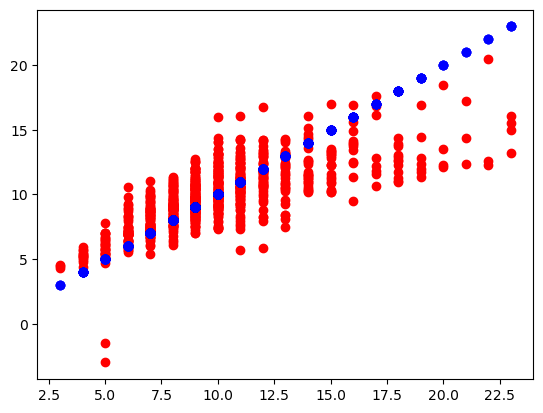

In [14]:
plt.scatter(Y_test, y_pred_ridge, color="r")
plt.scatter(Y_test, Y_test, color="b")
plt.show()

C:\Users\Pytla\AppData\Local\Temp\ipykernel_17636\1247844034.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


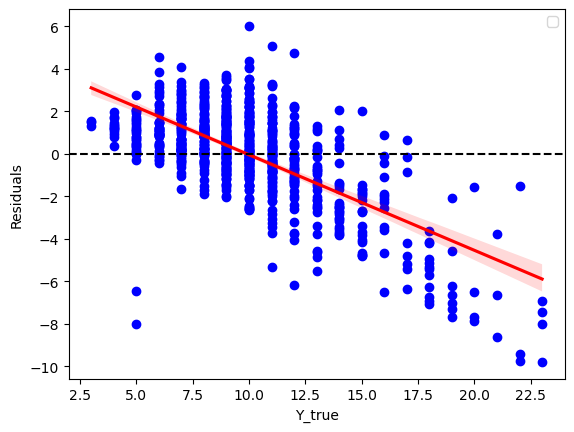

slope:  -0.4497025237212539
r:  -0.6690055351825656 p val:  1.3973210113031755e-109


In [37]:
from scipy.stats import linregress
residuals = y_pred_ridge - Y_test
slope, intercept, r_value, p_value, std_err = linregress(Y_test, residuals)
plt.scatter(Y_test, residuals, color="blue")
sns.regplot(x=Y_test, y=residuals, color="red", order=1, scatter=False)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Y_true")
plt.ylabel("Residuals")
plt.legend()
plt.show()

print("slope: ", slope)
print("r: ", r_value, "p val: ", p_value)

In [42]:
best_svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select", RFE(estimator=Ridge(alpha=1.0),  # estimator dla RFE można dobrać np. Ridge
                           n_features_to_select=best_svr_params["n_features"])),
    ("model", SVR(**{k: v for k, v in best_svr_params.items() if k not in ["n_features", "model", "alpha"]}))
])

best_svr_model.fit(X_train, Y_train)
y_pred_svr = best_svr_model.predict(X_test)
print("SVR R2:", r2_score(Y_test, y_pred_svr))
print("SVR MSE:", mean_squared_error(Y_test, y_pred_svr))

SVR R2: 0.5537941003359771
SVR MSE: 4.830272587430032


Shapiro-Wilk Test:  ShapiroResult(statistic=np.float64(0.9142213156241996), pvalue=np.float64(2.497855866346317e-21))


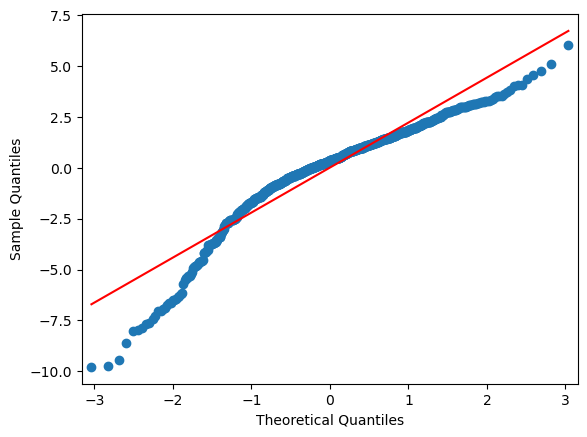

In [47]:
def shapiro_test(y_pred): # pozwala nam sprawdzic czy nasze dane pochodza z rozkladu normalnego
    diff = y_pred - Y_test
    shapiro_test = stats.shapiro(diff)
    print("Shapiro-Wilk Test: ", shapiro_test)

    sm.qqplot(diff, line="s")
    plt.show()

shapiro_test(y_pred_ridge)


Shapiro-Wilk Test:  ShapiroResult(statistic=np.float64(0.9014626001256305), pvalue=np.float64(9.211190352083457e-23))


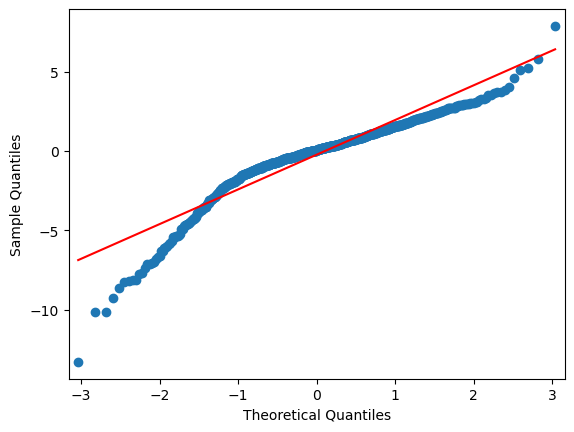

In [48]:
shapiro_test(y_pred_svr)

# i would say it is quite close to the normal distribution and i wouldn't deny it but I can't either prove that is a normal distribution
# in both cases: RidgeR, and the SVR method.

In [105]:
# Przyklad

arr = np.array([np.random.randint(20) for i in range(20)])
ground_truth = np.array([np.random.randint(20) for i in range(20)])
arr = np.sort(arr)
SSE = sum((arr-ground_truth)**2)
n = len(arr)
if n % 2 == 0:
    m = n//2
else: m = (n-1)//2


a = np.random.rand(m)

y = arr  # albo inna tablica, np. ground_truth

b = np.sum([a[i] * (y[n-1-i] - y[i]) for i in range(m)])


W = b**2 / SSE
print("Statystyka W =", W)


dif = arr - ground_truth
W,p_val = stats.shapiro(dif)
print(W, p_val)

Statystyka W = 1.7094834623227535
0.9746596804061636 0.8485177685885178
